
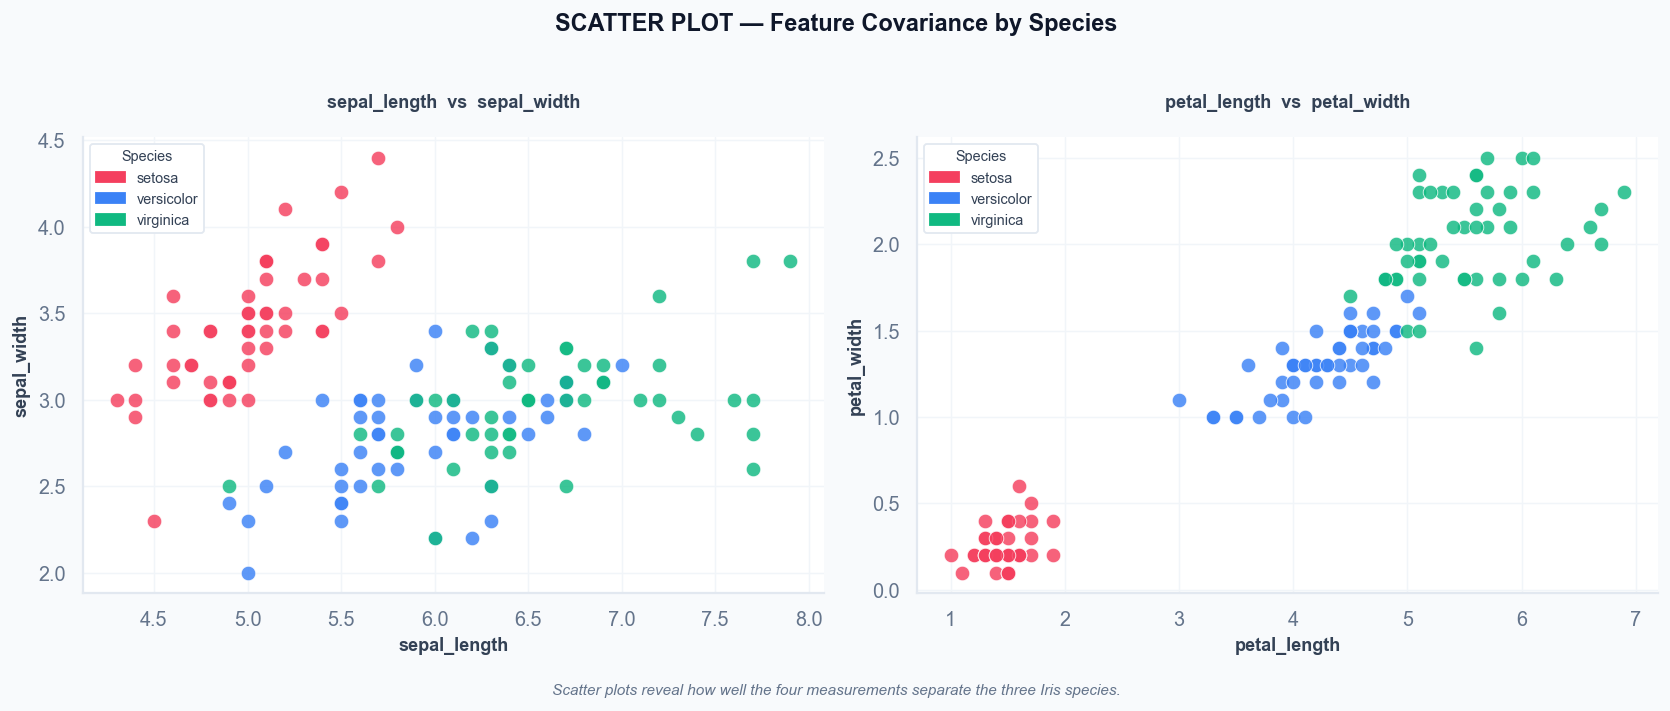
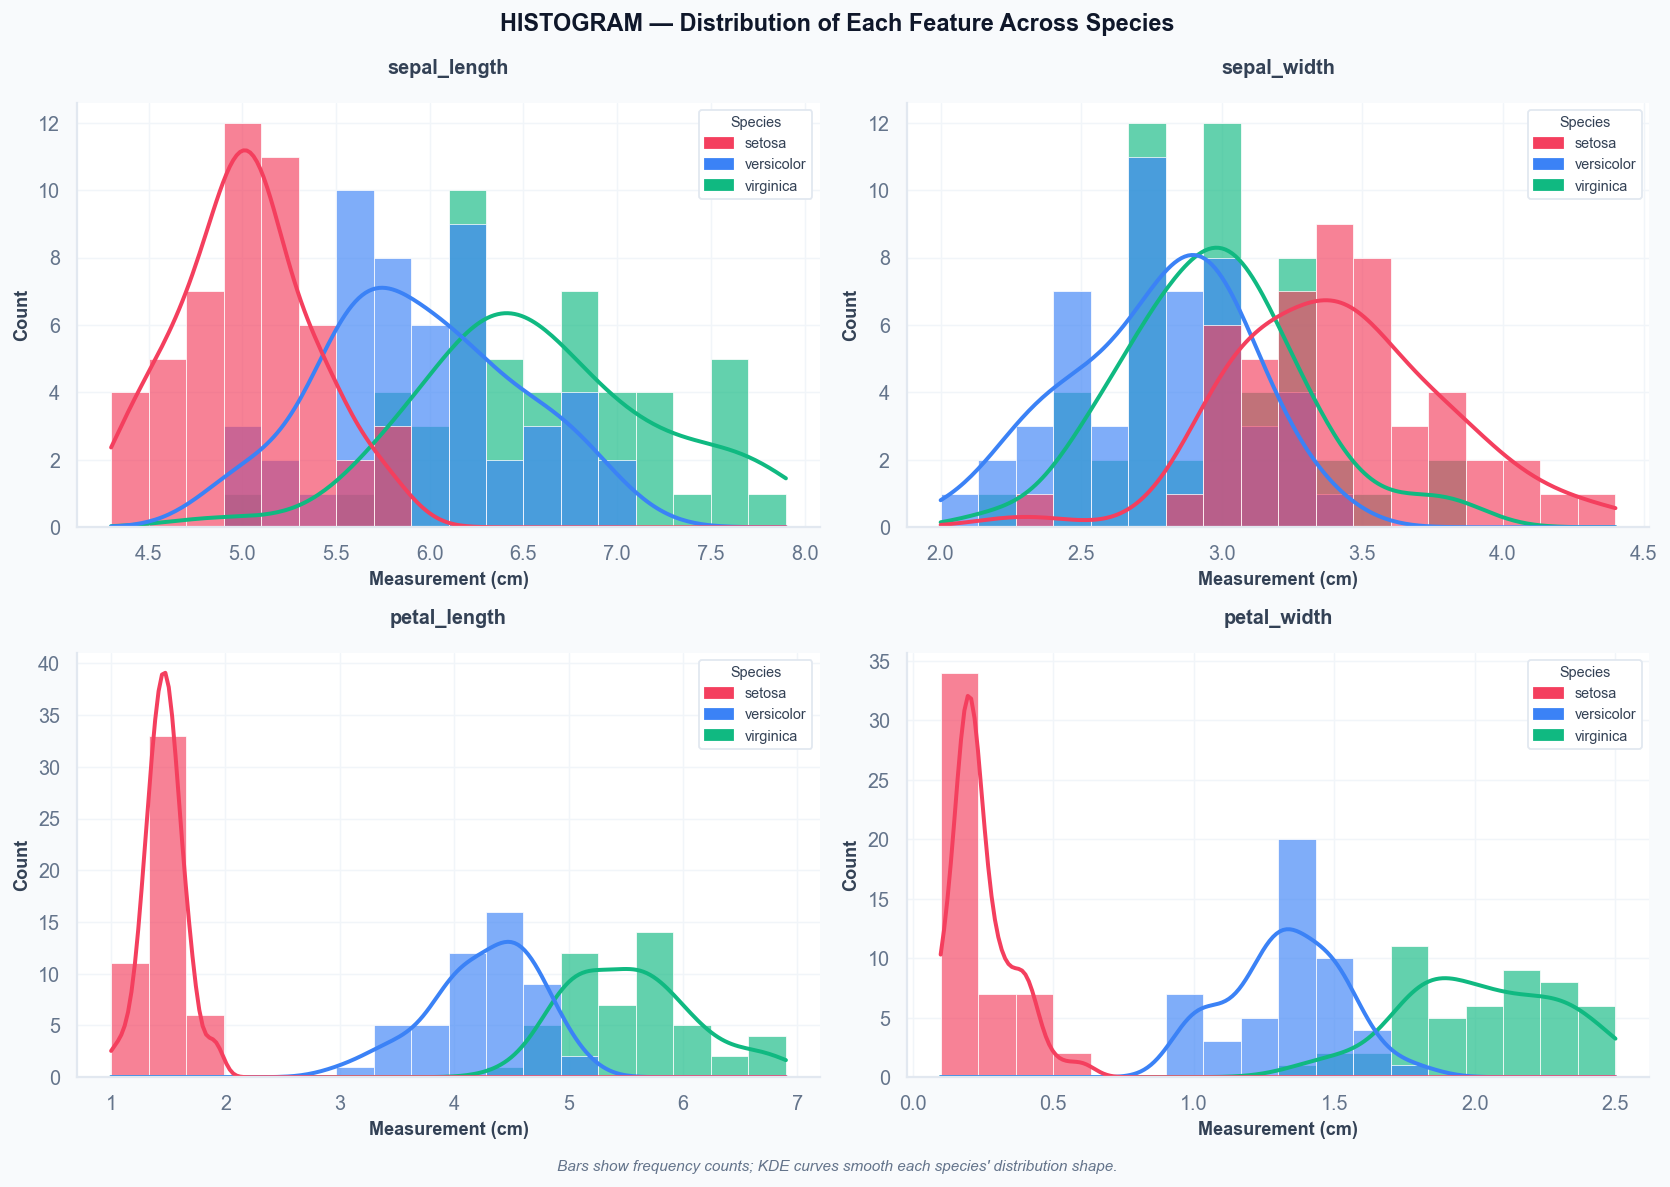
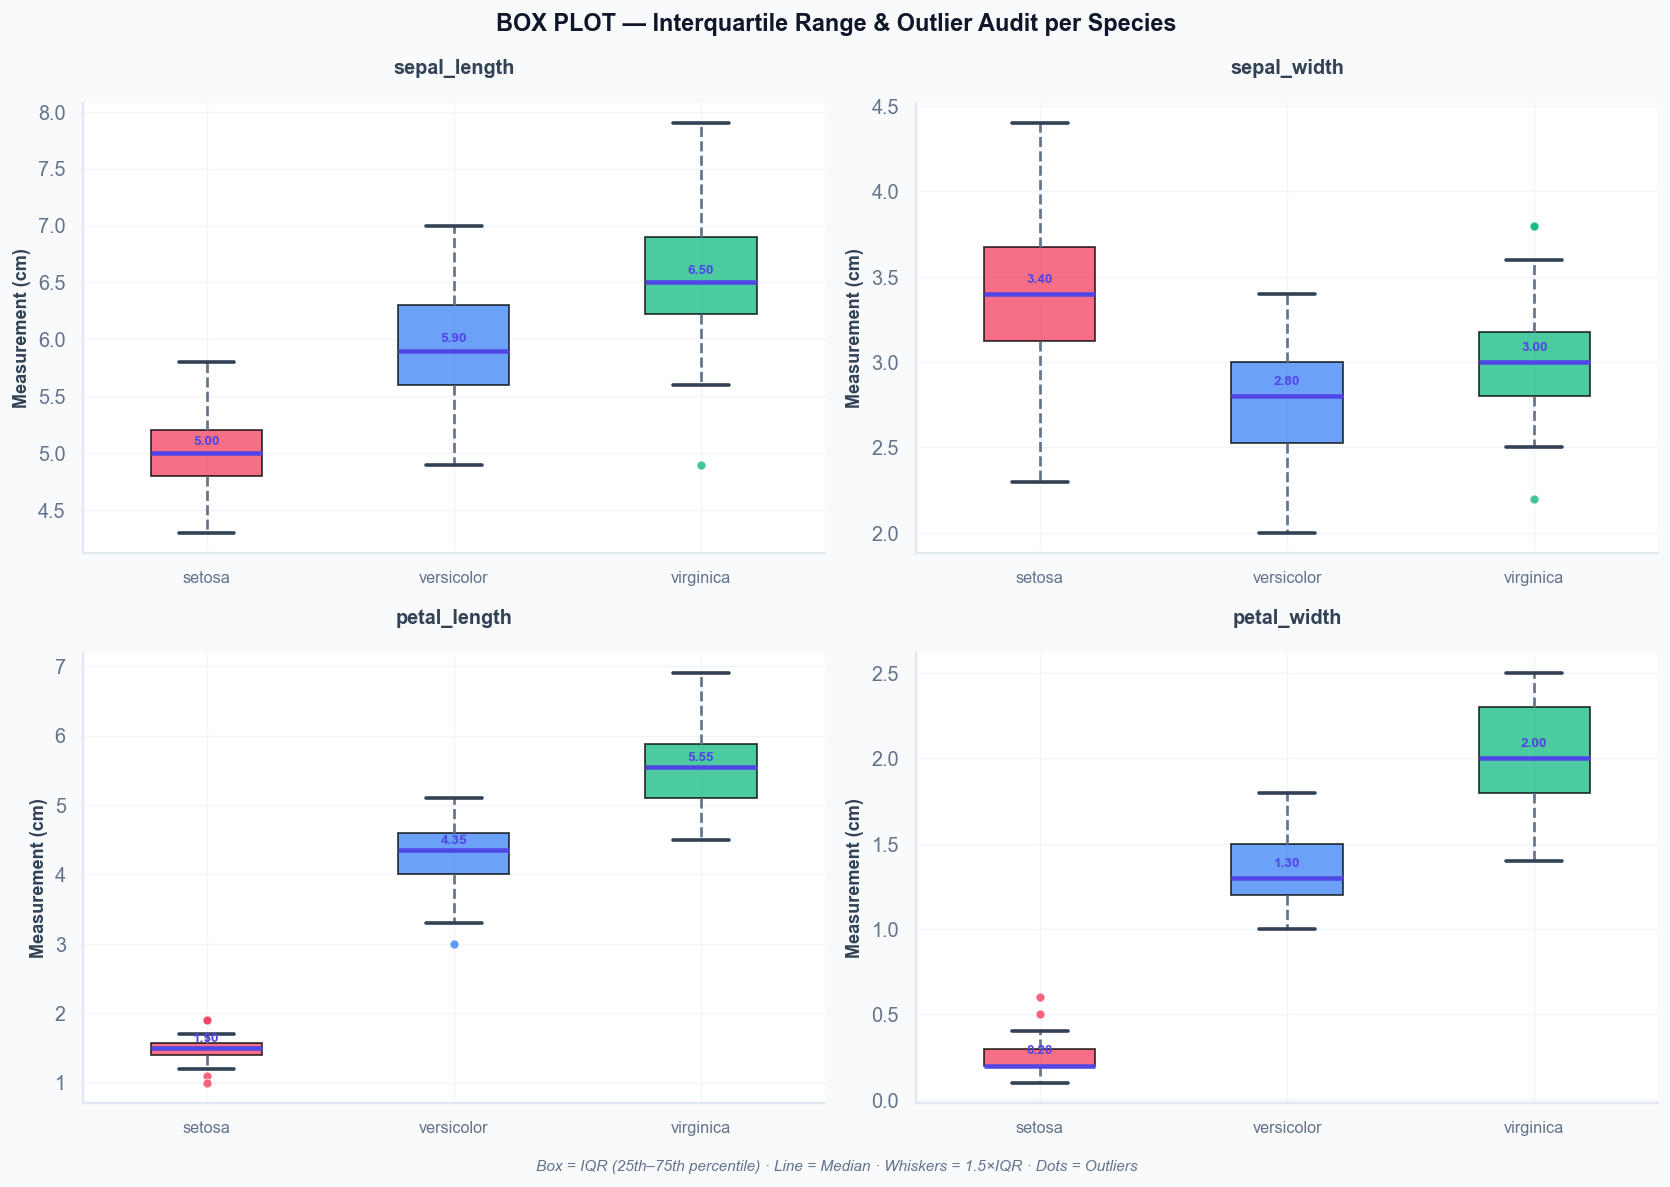
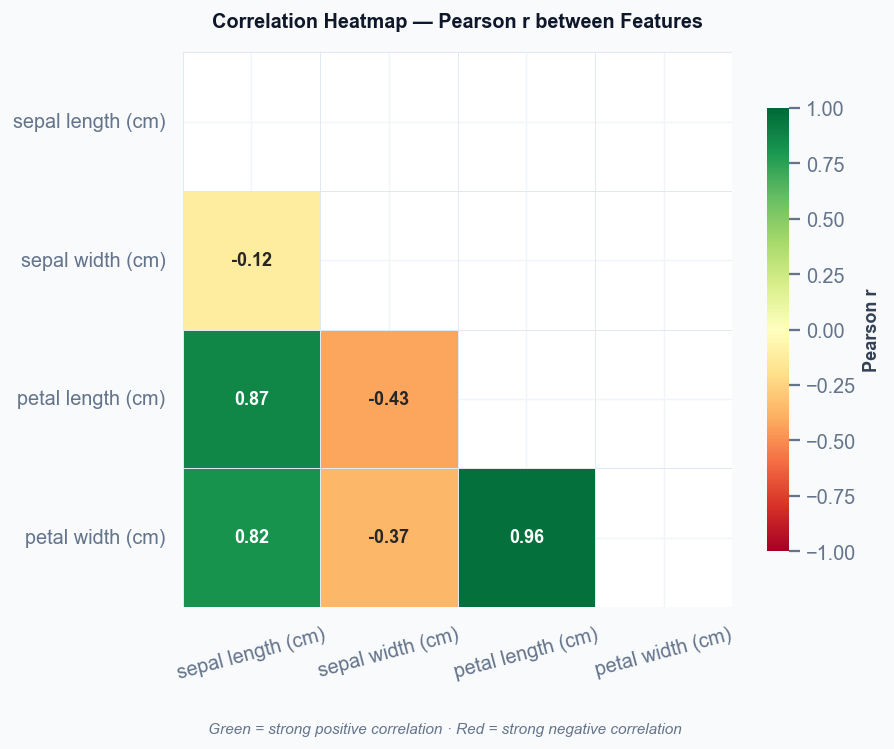

In [9]:
# =============================================================================
#  🌸 IRIS DATASET — PROFESSIONAL ANALYSIS & INTERACTIVE DASHBOARD
#  Task 1: Exploring and Visualizing a Simple Dataset
#  Tools: pandas · matplotlib · seaborn · sklearn · IPython
# =============================================================================

import numpy as np
import pandas as pd
import warnings
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from IPython.display import HTML as JupyterHTML, display

warnings.filterwarnings("ignore")
%matplotlib inline

# ─────────────────────────────────────────────────────────────────────────────
#  GLOBAL DESIGN TOKENS
# ─────────────────────────────────────────────────────────────────────────────
THEME_PALETTE  = ["#f43f5e", "#3b82f6", "#10b981"]   # Setosa · Versicolor · Virginica
PRIMARY_ACCENT = "#4f46e5"
BG_LIGHT       = "#f8fafc"
BG_CARD        = "#ffffff"
BORDER         = "#e2e8f0"
TEXT_DARK      = "#0f172a"
TEXT_MID       = "#334155"
TEXT_MUTED     = "#64748b"

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize"   : (11, 6),
    "axes.facecolor"   : BG_CARD,
    "figure.facecolor" : BG_LIGHT,
    "axes.edgecolor"   : BORDER,
    "axes.labelcolor"  : TEXT_MID,
    "text.color"       : TEXT_MID,
    "xtick.color"      : TEXT_MUTED,
    "ytick.color"      : TEXT_MUTED,
    "font.family"      : "sans-serif",
    "axes.titlepad"    : 16,
    "axes.titleweight" : "bold",
    "axes.titlesize"   : 13,
    "axes.labelsize"   : 10,
    "axes.labelweight" : "bold",
    "legend.frameon"   : True,
    "legend.framealpha": 1.0,
    "legend.edgecolor" : BORDER,
    "legend.facecolor" : BG_CARD,
    "grid.color"       : "#f1f5f9",
    "grid.linewidth"   : 0.8,
})


# ─────────────────────────────────────────────────────────────────────────────
#  STEP  — DATA LOADING
# ─────────────────────────────────────────────────────────────────────────────
file_path = "C:/Users/HP/OneDrive/Desktop/DS/iris.csv"
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    df = pd.read_csv("https://raw.githubusercontent.com/datasets/iris/master/data/iris.csv")

df.columns = [c.strip() for c in df.columns]
for id_col in ["Id", "id", "ID", "INDEX", "index"]:
    if id_col in df.columns:
        df.drop(columns=[id_col], inplace=True)

target_col = next(c for c in df.columns if c.lower() in ["species", "class", "target"])
features   = [c for c in df.columns if c != target_col]
classes_sorted = sorted(df[target_col].unique())
palette_dict   = {cls: THEME_PALETTE[i] for i, cls in enumerate(classes_sorted)}


# ─────────────────────────────────────────────────────────────────────────────
#  STEP  — ML PIPELINE
# ─────────────────────────────────────────────────────────────────────────────
encoder = LabelEncoder()
df["__target__"] = encoder.fit_transform(df[target_col])
X = df[features].values
y = df["__target__"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])
pipeline.fit(X_train, y_train)

y_pred      = pipeline.predict(X_test)
accuracy    = accuracy_score(y_test, y_pred)
skf         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores   = cross_val_score(pipeline, X, y, cv=skf, scoring="accuracy")
cm          = confusion_matrix(y_test, y_pred)
report      = classification_report(y_test, y_pred, target_names=encoder.classes_, output_dict=True)
importances = pipeline.named_steps["clf"].feature_importances_


# ─────────────────────────────────────────────────────────────────────────────
#  STEP  — MATPLOTLIB / SEABORN PLOTS (saved as base64 for dashboard)
# ─────────────────────────────────────────────────────────────────────────────
import io, base64

def fig_to_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=130, bbox_inches="tight", facecolor=fig.get_facecolor())
    buf.seek(0)
    return base64.b64encode(buf.read()).decode()

legend_patches = [
    mpatches.Patch(color=THEME_PALETTE[i], label=cls)
    for i, cls in enumerate(classes_sorted)
]


# ─────────────────────────────────────────────────────────────────────────────
#  STEP  — DATA ENCODING FOR DASHBOARD
# ─────────────────────────────────────────────────────────────────────────────
class_counts  = df[target_col].value_counts().to_dict()
feature_stats = {
    feat: {cls: df[df[target_col]==cls][feat].tolist() for cls in encoder.classes_}
    for feat in features
}

# Raw dataset → JSON (all 150 rows)
raw_rows_json = df[[*features, target_col]].to_json(orient="records")

# Describe stats → JSON
desc = df[features].describe().T.reset_index()
desc.columns = ["feature","count","mean","std","min","q25","q50","q75","max"]
desc_json = desc.round(4).to_json(orient="records")

classes_json      = json.dumps(list(encoder.classes_))
cm_json           = json.dumps(cm.tolist())
cv_json           = json.dumps([round(s,4) for s in cv_scores])
importance_json   = json.dumps([round(v,4) for v in importances])
features_json     = json.dumps(features)
class_counts_json = json.dumps(class_counts)
feat_stats_json   = json.dumps(feature_stats)

# Scatter data for Chart.js
scatter_data = {
    cls: {
        "x": df[df[target_col]==cls][features[2]].tolist(),
        "y": df[df[target_col]==cls][features[3]].tolist()
    } for cls in encoder.classes_
}
scatter_json = json.dumps(scatter_data)

# HTML table rows
metrics_rows = "".join([f"""
  <tr>
    <td><span class="badge" style="background:rgba(79,70,229,0.1);color:{PRIMARY_ACCENT};">{cls}</span></td>
    <td>{report[cls]['precision']:.4f}</td>
    <td>{report[cls]['recall']:.4f}</td>
    <td>{report[cls]['f1-score']:.4f}</td>
    <td>{int(report[cls]['support'])}</td>
  </tr>""" for cls in encoder.classes_])

importance_rows = "".join([f"""
  <tr>
    <td><strong>{feat}</strong></td>
    <td><div class="prog-wrap"><div class="prog-fill" style="width:{imp*100:.1f}%;background:{PRIMARY_ACCENT}"></div></div></td>
    <td style="font-weight:700;color:{TEXT_MID};">{imp*100:.2f}%</td>
  </tr>""" for feat, imp in zip(features, importances)])

cv_bar_html = "".join([f"""
  <div style="display:flex;align-items:center;gap:8px;margin-bottom:6px;font-size:.82rem;">
    <div style="width:42px;color:{TEXT_MUTED};font-weight:600;">Fold {i+1}</div>
    <div class="prog-wrap" style="flex:1"><div class="prog-fill" style="width:{s*100:.1f}%;background:#0284c7"></div></div>
    <div style="width:52px;text-align:right;font-weight:700;color:{TEXT_MID};">{s*100:.2f}%</div>
  </div>""" for i, s in enumerate(cv_scores)])


# ─────────────────────────────────────────────────────────────────────────────
#  STEP  — FULL DASHBOARD HTML
# ─────────────────────────────────────────────────────────────────────────────
HTML_DASHBOARD = f"""
<div id="iris-dash" style="background:{BG_LIGHT};color:{TEXT_MID};
     font-family:'Segoe UI',system-ui,sans-serif;padding:2rem;border-radius:16px;
     border:1px solid {BORDER};max-height:98vh;overflow-y:auto;line-height:1.65;margin-top:20px;">
<style>
  #iris-dash {{ box-sizing:border-box; }}
  #iris-dash *,#iris-dash *::before,#iris-dash *::after {{ box-sizing:inherit; }}

  /* NAV TABS */
  .tab-bar  {{ display:flex;gap:6px;flex-wrap:wrap;margin-bottom:1.75rem;
               border-bottom:2px solid {BORDER};padding-bottom:0; }}
  .tab-btn  {{ padding:.55rem 1.1rem;border:none;border-bottom:3px solid transparent;
               background:none;cursor:pointer;font-weight:700;font-size:.82rem;
               color:{TEXT_MUTED};border-radius:6px 6px 0 0;transition:all .15s;white-space:nowrap; }}
  .tab-btn:hover  {{ color:{PRIMARY_ACCENT};background:rgba(79,70,229,.05); }}
  .tab-btn.active {{ color:{PRIMARY_ACCENT};border-bottom-color:{PRIMARY_ACCENT};background:rgba(79,70,229,.06); }}
  .tab-pane {{ display:none; }}
  .tab-pane.active {{ display:block; }}

  /* LAYOUT */
  .kpi-grid  {{ display:grid;grid-template-columns:repeat(auto-fit,minmax(180px,1fr));gap:1rem;margin-bottom:1.75rem; }}
  .kpi       {{ background:{BG_CARD};border:1px solid {BORDER};border-radius:12px;padding:1.1rem 1.4rem;
                box-shadow:0 1px 3px rgba(0,0,0,.04); }}
  .kpi-lbl   {{ color:{TEXT_MUTED};font-size:.7rem;text-transform:uppercase;letter-spacing:.06em;font-weight:700;margin-bottom:.2rem; }}
  .kpi-val   {{ font-size:1.85rem;font-weight:900; }}
  .card-grid {{ display:grid;grid-template-columns:repeat(auto-fit,minmax(360px,1fr));gap:1.4rem;margin-bottom:1.4rem; }}
  .card      {{ background:{BG_CARD};border:1px solid {BORDER};border-radius:12px;padding:1.4rem;
                box-shadow:0 1px 3px rgba(0,0,0,.04); }}
  .sec-title {{ font-size:.95rem;font-weight:700;color:#1e293b;border-left:4px solid {PRIMARY_ACCENT};
                padding-left:8px;margin-bottom:1rem; }}
  .chart-sm  {{ position:relative;height:210px; }}
  .chart-md  {{ position:relative;height:270px; }}

  /* TABLES */
  .tbl-wrap  {{ overflow-x:auto;border-radius:8px;border:1px solid {BORDER};margin-top:.4rem; }}
  table      {{ width:100%;border-collapse:collapse;font-size:.82rem;text-align:left;background:{BG_CARD}; }}
  thead tr   {{ background:#f1f5f9;border-bottom:2px solid {BORDER}; }}
  th,td      {{ padding:.6rem .9rem;border-bottom:1px solid {BORDER};color:{TEXT_MID}; }}
  th         {{ font-weight:700;color:#1e293b; }}
  tr:last-child td {{ border-bottom:none; }}
  tr:hover td {{ background:#fafafa; }}
  .badge     {{ display:inline-block;padding:.18rem .6rem;border-radius:999px;font-size:.68rem;font-weight:700; }}

  /* PROGRESS */
  .prog-wrap {{ background:#f1f5f9;border-radius:999px;height:7px;overflow:hidden;min-width:80px; }}
  .prog-fill {{ height:100%;border-radius:999px; }}

  /* CONFUSION MATRIX */
  .cm-grid  {{ display:grid;gap:5px;justify-content:center;margin:10px auto; }}
  .cm-hdr   {{ width:84px;height:32px;display:flex;align-items:center;justify-content:center;
               font-size:.65rem;color:{TEXT_MUTED};font-weight:700;text-transform:uppercase;text-align:center; }}
  .cm-cell  {{ width:84px;height:84px;border-radius:8px;display:flex;flex-direction:column;
               align-items:center;justify-content:center;font-weight:700;font-size:1.15rem;
               border:1px solid {BORDER}; }}
  .cm-cell span {{ font-size:.58rem;font-weight:600;text-transform:uppercase;opacity:.8;margin-top:2px; }}

  /* PREDICT */
  .pf      {{ background:{BG_LIGHT};border:1px solid {BORDER};border-radius:12px;padding:1.5rem; }}
  .fg-grid {{ display:grid;grid-template-columns:repeat(auto-fit,minmax(148px,1fr));gap:.9rem;margin-bottom:1rem; }}
  .fg label {{ display:block;color:{TEXT_MUTED};font-size:.7rem;font-weight:700;margin-bottom:.3rem; }}
  .fg input {{ width:100%;background:{BG_CARD};border:1px solid #cbd5e1;border-radius:8px;
               padding:.5rem;color:#1e293b;outline:none;font-weight:600;font-size:.88rem;transition:border-color .2s; }}
  .fg input:focus {{ border-color:{PRIMARY_ACCENT}; }}
  .btn {{ background:{PRIMARY_ACCENT};border:none;border-radius:8px;padding:.65rem 1.7rem;color:#fff;
          font-weight:700;cursor:pointer;font-size:.88rem;
          box-shadow:0 2px 6px rgba(79,70,229,.25);transition:opacity .2s; }}
  .btn:hover {{ opacity:.88; }}
  .res-box {{ margin-top:1.1rem;background:{BG_CARD};border:1px solid {BORDER};
              border-left:5px solid #10b981;border-radius:8px;padding:1.1rem;
              display:none;box-shadow:0 4px 8px rgba(0,0,0,.05); }}
  .plot-tag {{ display:inline-block;background:rgba(79,70,229,.09);color:{PRIMARY_ACCENT};
               font-size:.68rem;font-weight:700;padding:.18rem .6rem;border-radius:999px;
               margin-bottom:.65rem;text-transform:uppercase;letter-spacing:.05em; }}
  .img-plot {{ width:100%;border-radius:10px;border:1px solid {BORDER}; }}
  .insight  {{ background:rgba(79,70,229,.05);border-left:3px solid {PRIMARY_ACCENT};
               border-radius:0 8px 8px 0;padding:.6rem .9rem;font-size:.82rem;
               color:{TEXT_MID};margin-top:.75rem; }}

  /* SEARCH */
  #rawSearch {{ width:100%;padding:.5rem .8rem;border:1px solid #cbd5e1;border-radius:8px;
                font-size:.85rem;outline:none;margin-bottom:.75rem;color:#1e293b; }}
  #rawSearch:focus {{ border-color:{PRIMARY_ACCENT}; }}

  /* SPECIES COLOR DOTS */
  .dot {{ width:9px;height:9px;border-radius:50%;display:inline-block;margin-right:5px; }}
</style>

<!-- ══ HEADER ══════════════════════════════════════════════════════════════ -->
<div style="border-bottom:1px solid {BORDER};padding-bottom:1.1rem;margin-bottom:1.6rem;
            display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:10px;">
  <div>
    <h2 style="font-size:1.7rem;font-weight:900;color:{TEXT_DARK};margin:0;">
      🌸 Iris Dataset — Full Analysis Dashboard
    </h2>
    <p style="color:{TEXT_MUTED};font-size:.83rem;margin:3px 0 0;">
      Task 1 · Data Exploration · Visualization · Machine Learning · 150 samples · 3 species · 4 features
    </p>
  </div>
  <div style="display:flex;gap:8px;align-items:center;flex-wrap:wrap;">
    <span style="background:#dcfce7;color:#16a34a;padding:.3rem .75rem;border-radius:999px;font-size:.72rem;font-weight:700;">🟢 Pipeline Active</span>
    <span style="background:rgba(79,70,229,.1);color:{PRIMARY_ACCENT};padding:.3rem .75rem;border-radius:999px;font-size:.72rem;font-weight:700;">RF · 300 Trees</span>
  </div>
</div>

<!-- ══ KPI ROW ══════════════════════════════════════════════════════════════ -->
<div class="kpi-grid">
  <div class="kpi">
    <div class="kpi-lbl">Dataset Size</div>
    <div class="kpi-val" style="color:{TEXT_DARK}">150</div>
    <div style="font-size:.72rem;color:{TEXT_MUTED};margin-top:2px;">rows × 5 columns</div>
  </div>
  <div class="kpi">
    <div class="kpi-lbl">Features</div>
    <div class="kpi-val" style="color:#0284c7">4</div>
    <div style="font-size:.72rem;color:{TEXT_MUTED};margin-top:2px;">sepal & petal dims</div>
  </div>
  <div class="kpi">
    <div class="kpi-lbl">Test Accuracy</div>
    <div class="kpi-val" style="color:{PRIMARY_ACCENT}">{accuracy*100:.2f}%</div>
    <div style="font-size:.72rem;color:{TEXT_MUTED};margin-top:2px;">80/20 stratified split</div>
  </div>
  <div class="kpi">
    <div class="kpi-lbl">CV Mean (5-Fold)</div>
    <div class="kpi-val" style="color:#10b981">{cv_scores.mean()*100:.2f}%</div>
    <div style="font-size:.72rem;color:{TEXT_MUTED};margin-top:2px;">±{cv_scores.std()*100:.2f}% std dev</div>
  </div>
  <div class="kpi">
    <div class="kpi-lbl">Classes</div>
    <div class="kpi-val" style="color:#f43f5e">3</div>
    <div style="font-size:.72rem;color:{TEXT_MUTED};margin-top:2px;">50 samples each</div>
  </div>
</div>

<!-- ══ NAV TABS ═════════════════════════════════════════════════════════════ -->
<div class="tab-bar">
  <button class="tab-btn active" onclick="showTab('overview',this)">📊 Overview</button>
  <button class="tab-btn" onclick="showTab('scatter',this)">🔵 Scatter Plot</button>
  <button class="tab-btn" onclick="showTab('histogram',this)">📶 Histogram</button>
  <button class="tab-btn" onclick="showTab('boxplot',this)">📦 Box Plot</button>
  <button class="tab-btn" onclick="showTab('heatmap',this)">🌡️ Heatmap</button>
  <button class="tab-btn" onclick="showTab('stats',this)">📋 Statistics</button>
  <button class="tab-btn" onclick="showTab('rawdata',this)">🗃️ Raw Data</button>
  <button class="tab-btn" onclick="showTab('model',this)">🤖 Model</button>
  <button class="tab-btn" onclick="showTab('predict',this)">⚡ Predict</button>
</div>

<!-- ══════════════════════════════════════════════════════════════════════════
     TAB 1 · OVERVIEW
══════════════════════════════════════════════════════════════════════════════ -->
<div id="tab-overview" class="tab-pane active">
  <div class="card-grid">
    <div class="card">
      <div class="plot-tag">Doughnut Chart</div>
      <div class="sec-title">Class Distribution Balance</div>
      <div class="chart-sm"><canvas id="classChart"></canvas></div>
    </div>
    <div class="card">
      <div class="plot-tag">Grouped Bar Chart</div>
      <div class="sec-title">Feature Mean Values by Species</div>
      <div class="chart-md"><canvas id="meanChart"></canvas></div>
    </div>
  </div>
  <div class="card-grid">
    <div class="card">
      <div class="plot-tag">Radar Chart</div>
      <div class="sec-title">Normalised Feature Profile per Species</div>
      <div class="chart-sm"><canvas id="radarChart"></canvas></div>
    </div>
    <div class="card">
      <div class="plot-tag">Interactive Scatter</div>
      <div class="sec-title">Petal Length vs Petal Width (all 150 pts)</div>
      <div class="chart-md"><canvas id="scatterChart"></canvas></div>
    </div>
  </div>
</div>

<!-- ══════════════════════════════════════════════════════════════════════════
     TAB 2 · SCATTER PLOT
══════════════════════════════════════════════════════════════════════════════ -->
<div id="tab-scatter" class="tab-pane">
  <div class="card">
    <div class="plot-tag">Matplotlib Scatter Plot</div>
    <div class="sec-title">Scatter Plot — Pairwise Feature Covariance by Species</div>
    <img src="data:image/png;base64,{scatter_b64}" class="img-plot" alt="Scatter Plot"/>
    <div class="insight">
      💡 <strong>What is a Scatter Plot?</strong> Each point represents one flower sample.
      The X and Y axes show two different measurements. Points are coloured by species so you can
      see how well measurements separate the classes.<br><br>
      <strong>Key finding:</strong> Petal length vs petal width (right panel) separates the three
      species almost perfectly. Setosa forms a tight cluster at the bottom-left; Versicolor and
      Virginica have some overlap.
    </div>
  </div>
</div>

<!-- ══════════════════════════════════════════════════════════════════════════
     TAB 3 · HISTOGRAM
══════════════════════════════════════════════════════════════════════════════ -->
<div id="tab-histogram" class="tab-pane">
  <div class="card">
    <div class="plot-tag">Seaborn Histogram + KDE</div>
    <div class="sec-title">Histogram — Frequency Distribution per Feature per Species</div>
    <img src="data:image/png;base64,{hist_b64}" class="img-plot" alt="Histogram"/>
    <div class="insight">
      💡 <strong>What is a Histogram?</strong> The X-axis shows measurement values split into bins
      (ranges). The Y-axis shows how many flowers fall in each bin. The smooth KDE curve shows the
      overall shape of the distribution for each species.<br><br>
      <strong>Key finding:</strong> Setosa (red) is clearly separated in both petal measurements.
      Sepal width shows the most overlap between all three species, making it the least useful
      feature on its own.
    </div>
  </div>
</div>

<!-- ══════════════════════════════════════════════════════════════════════════
     TAB 4 · BOX PLOT
══════════════════════════════════════════════════════════════════════════════ -->
<div id="tab-boxplot" class="tab-pane">
  <div class="card">
    <div class="plot-tag">Matplotlib Box Plot</div>
    <div class="sec-title">Box Plot — IQR, Spread & Outlier Detection per Species</div>
    <img src="data:image/png;base64,{box_b64}" class="img-plot" alt="Box Plot"/>
    <div class="insight">
      💡 <strong>What is a Box Plot?</strong>
      <strong>Box</strong> = middle 50% of data (IQR: 25th–75th percentile).
      <strong>Line inside box</strong> = median value (annotated in purple).
      <strong>Whiskers</strong> = extend to 1.5× the IQR.
      <strong>Dots beyond whiskers</strong> = outliers.<br><br>
      <strong>Key finding:</strong> Setosa has very small petal measurements with tight spread
      (low variance). A few outliers appear in sepal width across all classes.
    </div>
  </div>
</div>

<!-- ══════════════════════════════════════════════════════════════════════════
     TAB 5 · HEATMAP
══════════════════════════════════════════════════════════════════════════════ -->
<div id="tab-heatmap" class="tab-pane">
  <div class="card" style="max-width:600px;margin:0 auto;">
    <div class="plot-tag">Seaborn Heatmap</div>
    <div class="sec-title">Correlation Heatmap — Pearson r between Features</div>
    <img src="data:image/png;base64,{heatmap_b64}" class="img-plot" alt="Heatmap"/>
    <div class="insight">
      💡 <strong>What is a Correlation Heatmap?</strong> Each cell shows the Pearson r correlation
      coefficient between two features. <strong>+1.0</strong> (dark green) = perfect positive
      correlation. <strong>−1.0</strong> (dark red) = perfect negative correlation.
      <strong>0</strong> = no linear relationship.<br><br>
      <strong>Key finding:</strong> Petal length ↔ petal width (r ≈ 0.96) are almost perfectly
      correlated — they carry nearly the same information. Sepal width is barely correlated with
      any other feature.
    </div>
  </div>
</div>

<!-- ══════════════════════════════════════════════════════════════════════════
     TAB 6 · STATISTICS
══════════════════════════════════════════════════════════════════════════════ -->
<div id="tab-stats" class="tab-pane">
  <div class="card" style="margin-bottom:1.4rem;">
    <div class="plot-tag">df.describe()</div>
    <div class="sec-title">Statistical Summary — All Features</div>
    <div class="tbl-wrap">
      <table>
        <thead>
          <tr><th>Feature</th><th>Count</th><th>Mean</th><th>Std Dev</th>
              <th>Min</th><th>Q1 (25%)</th><th>Median</th><th>Q3 (75%)</th><th>Max</th></tr>
        </thead>
        <tbody id="descBody"></tbody>
      </table>
    </div>
  </div>
  <div class="card">
    <div class="plot-tag">Per-Class Statistics</div>
    <div class="sec-title">Mean ± Std Dev per Species</div>
    <div class="tbl-wrap">
      <table>
        <thead>
          <tr><th>Feature</th>
              <th><span class="dot" style="background:#f43f5e"></span>Setosa</th>
              <th><span class="dot" style="background:#3b82f6"></span>Versicolor</th>
              <th><span class="dot" style="background:#10b981"></span>Virginica</th>
          </tr>
        </thead>
        <tbody id="classStatsBody"></tbody>
      </table>
    </div>
  </div>
</div>

<!-- ══════════════════════════════════════════════════════════════════════════
     TAB 7 · RAW DATA
══════════════════════════════════════════════════════════════════════════════ -->
<div id="tab-rawdata" class="tab-pane">
  <div class="card">
    <div class="plot-tag">Full Dataset</div>
    <div class="sec-title">Raw Data — All 150 Samples</div>
    <input id="rawSearch" placeholder="🔍  Search by species name or value …" oninput="filterTable()"/>
    <div style="font-size:.78rem;color:{TEXT_MUTED};margin-bottom:.5rem;" id="rowCount">Showing 150 of 150 rows</div>
    <div class="tbl-wrap" style="max-height:420px;overflow-y:auto;">
      <table id="rawTable">
        <thead>
          <tr id="rawHead"></tr>
        </thead>
        <tbody id="rawBody"></tbody>
      </table>
    </div>
  </div>
</div>

<!-- ══════════════════════════════════════════════════════════════════════════
     TAB 8 · MODEL
══════════════════════════════════════════════════════════════════════════════ -->
<div id="tab-model" class="tab-pane">
  <div class="card-grid">
    <div class="card">
      <div class="plot-tag">Classification Report</div>
      <div class="sec-title">Model Performance by Class</div>
      <div class="tbl-wrap">
        <table>
          <thead><tr><th>Species</th><th>Precision</th><th>Recall</th><th>F1-Score</th><th>Support</th></tr></thead>
          <tbody>{metrics_rows}</tbody>
        </table>
      </div>
    </div>
    <div class="card">
      <div class="plot-tag">Confusion Matrix</div>
      <div class="sec-title">Prediction Hit / Miss Matrix</div>
      <div id="cmContainer"></div>
    </div>
  </div>
  <div class="card-grid">
    <div class="card">
      <div class="plot-tag">Feature Importance</div>
      <div class="sec-title">Random Forest Feature Rankings</div>
      <div class="tbl-wrap">
        <table>
          <thead><tr><th>Feature</th><th>Importance Bar</th><th>Score</th></tr></thead>
          <tbody>{importance_rows}</tbody>
        </table>
      </div>
    </div>
    <div class="card">
      <div class="plot-tag">Cross-Validation</div>
      <div class="sec-title">Stratified 5-Fold Accuracy per Fold</div>
      {cv_bar_html}
      <div style="margin-top:.9rem;padding-top:.9rem;border-top:1px solid {BORDER};
                  display:flex;gap:1.5rem;font-size:.82rem;">
        <div><span style="color:{TEXT_MUTED};font-weight:600;">Mean</span>
             <strong style="color:{PRIMARY_ACCENT};margin-left:6px;">{cv_scores.mean()*100:.2f}%</strong></div>
        <div><span style="color:{TEXT_MUTED};font-weight:600;">Std Dev</span>
             <strong style="color:#f43f5e;margin-left:6px;">{cv_scores.std()*100:.2f}%</strong></div>
        <div><span style="color:{TEXT_MUTED};font-weight:600;">Min</span>
             <strong style="color:{TEXT_MID};margin-left:6px;">{cv_scores.min()*100:.2f}%</strong></div>
        <div><span style="color:{TEXT_MUTED};font-weight:600;">Max</span>
             <strong style="color:#10b981;margin-left:6px;">{cv_scores.max()*100:.2f}%</strong></div>
      </div>
    </div>
  </div>
</div>

<!-- ══════════════════════════════════════════════════════════════════════════
     TAB 9 · PREDICT
══════════════════════════════════════════════════════════════════════════════ -->
<div id="tab-predict" class="tab-pane">
  <div class="pf">
    <div class="plot-tag">Live Inference</div>
    <div class="sec-title" style="color:{TEXT_DARK};">Real-Time Species Prediction</div>
    <p style="font-size:.83rem;color:{TEXT_MUTED};margin:0 0 1rem;">
      Enter the four flower measurements below. The model will predict which Iris species it belongs to.
    </p>
    <div class="fg-grid">
      <div class="fg"><label>Sepal Length (cm)</label><input type="number" id="d_sl" step="0.1" value="5.1" min="0"/></div>
      <div class="fg"><label>Sepal Width (cm)</label> <input type="number" id="d_sw" step="0.1" value="3.5" min="0"/></div>
      <div class="fg"><label>Petal Length (cm)</label><input type="number" id="d_pl" step="0.1" value="1.4" min="0"/></div>
      <div class="fg"><label>Petal Width (cm)</label> <input type="number" id="d_pw" step="0.1" value="0.2" min="0"/></div>
    </div>
    <button class="btn" onclick="doPredict()">▶ Predict Species</button>
    <div style="display:flex;gap:.5rem;margin-top:.75rem;flex-wrap:wrap;">
      <button onclick="setVals(5.1,3.5,1.4,0.2)" style="padding:.35rem .8rem;border:1px solid {BORDER};
        border-radius:6px;background:{BG_CARD};font-size:.78rem;cursor:pointer;font-weight:600;">
        🔴 Try Setosa</button>
      <button onclick="setVals(5.9,3.0,4.2,1.5)" style="padding:.35rem .8rem;border:1px solid {BORDER};
        border-radius:6px;background:{BG_CARD};font-size:.78rem;cursor:pointer;font-weight:600;">
        🔵 Try Versicolor</button>
      <button onclick="setVals(6.5,3.0,5.5,1.8)" style="padding:.35rem .8rem;border:1px solid {BORDER};
        border-radius:6px;background:{BG_CARD};font-size:.78rem;cursor:pointer;font-weight:600;">
        🟢 Try Virginica</button>
    </div>
    <div class="res-box" id="resBox">
      <div style="font-size:.7rem;color:{TEXT_MUTED};text-transform:uppercase;font-weight:700;letter-spacing:.05em;">
        Predicted Species</div>
      <div id="resSpecies" style="font-size:1.6rem;font-weight:900;margin:4px 0 12px;"></div>
      <div id="resBars" style="display:flex;flex-direction:column;gap:.45rem;
                                border-top:1px solid #f1f5f9;padding-top:10px;"></div>
    </div>
  </div>
</div>

</div><!-- /iris-dash -->

<script>
// ── TAB SWITCHING ──────────────────────────────────────────────────────────
function showTab(name, btn) {{
  document.querySelectorAll('#iris-dash .tab-pane').forEach(p => p.classList.remove('active'));
  document.querySelectorAll('#iris-dash .tab-btn').forEach(b => b.classList.remove('active'));
  document.getElementById('tab-' + name).classList.add('active');
  btn.classList.add('active');
}}

// ── CHART.JS INIT ──────────────────────────────────────────────────────────
(function() {{
  function loadScript(src, cb) {{
    var s = document.createElement('script');
    s.src = src; s.onload = cb; document.head.appendChild(s);
  }}
  var CDN = 'https://cdn.jsdelivr.net/npm/chart.js@4.4.0/dist/chart.umd.min.js';
  if (typeof Chart === 'undefined') loadScript(CDN, init); else init();

  function init() {{
    const CLASSES  = {classes_json};
    const COUNTS   = {class_counts_json};
    const STATS    = {feat_stats_json};
    const FEATURES = {features_json};
    const CM       = {cm_json};
    const SCATTER  = {scatter_json};
    const PALETTE  = ['{THEME_PALETTE[0]}','{THEME_PALETTE[1]}','{THEME_PALETTE[2]}'];
    const DESC     = {desc_json};
    const RAWROWS  = {raw_rows_json};

    Chart.defaults.color       = '{TEXT_MUTED}';
    Chart.defaults.borderColor = '#f1f5f9';
    Chart.defaults.font.family = "'Segoe UI', system-ui, sans-serif";

    // ── Doughnut
    new Chart(document.getElementById('classChart'), {{
      type: 'doughnut',
      data: {{
        labels: Object.keys(COUNTS),
        datasets: [{{ data: Object.values(COUNTS), backgroundColor: PALETTE,
                     borderColor: '#fff', borderWidth: 3 }}]
      }},
      options: {{ responsive:true, maintainAspectRatio:false, cutout:'60%',
        plugins: {{ legend: {{ position:'bottom', labels:{{ boxWidth:12, font:{{ weight:'bold' }} }} }},
          tooltip: {{ callbacks: {{ label: ctx => ` ${{ctx.label}}: ${{ctx.raw}} samples (${{(ctx.raw/150*100).toFixed(0)}}%)` }} }} }}
      }}
    }});

    // ── Grouped Bar (means)
    const means = CLASSES.map(cls =>
      FEATURES.map(f => +(STATS[f][cls].reduce((a,b)=>a+b,0)/STATS[f][cls].length).toFixed(3))
    );
    new Chart(document.getElementById('meanChart'), {{
      type: 'bar',
      data: {{
        labels: FEATURES,
        datasets: CLASSES.map((cls,i) => ({{ label:cls, data:means[i],
          backgroundColor:PALETTE[i], borderRadius:5 }}))
      }},
      options: {{ responsive:true, maintainAspectRatio:false,
        plugins: {{ legend:{{ position:'bottom', labels:{{ boxWidth:12, font:{{ weight:'bold' }} }} }} }},
        scales: {{ y:{{ grid:{{ color:'#f1f5f9' }}, border:{{ display:false }},
                        title:{{ display:true, text:'cm', font:{{ weight:'bold' }} }} }},
                   x:{{ grid:{{ display:false }} }} }}
      }}
    }});

    // ── Radar (normalised means)
    const allMeans = FEATURES.map(f =>
      CLASSES.map(cls => STATS[f][cls].reduce((a,b)=>a+b,0)/STATS[f][cls].length)
    );
    const fMin = allMeans.map(row => Math.min(...row));
    const fMax = allMeans.map(row => Math.max(...row));
    const normMeans = CLASSES.map((cls,ci) =>
      FEATURES.map((f,fi) => +((allMeans[fi][ci]-fMin[fi])/(fMax[fi]-fMin[fi]||1)).toFixed(3))
    );
    new Chart(document.getElementById('radarChart'), {{
      type: 'radar',
      data: {{
        labels: FEATURES,
        datasets: CLASSES.map((cls,i) => ({{
          label: cls, data: normMeans[i],
          borderColor: PALETTE[i], backgroundColor: PALETTE[i].replace(')',',0.12)').replace('rgb','rgba'),
          pointBackgroundColor: PALETTE[i], borderWidth: 2, pointRadius: 4
        }}))
      }},
      options: {{ responsive:true, maintainAspectRatio:false,
        scales: {{ r:{{ min:0, max:1, ticks:{{ stepSize:.25, font:{{ size:9 }} }},
                        pointLabels:{{ font:{{ size:9, weight:'bold' }} }} }} }},
        plugins: {{ legend:{{ position:'bottom', labels:{{ boxWidth:12, font:{{ weight:'bold' }} }} }} }}
      }}
    }});

    // ── Interactive Scatter (petal L vs petal W)
    new Chart(document.getElementById('scatterChart'), {{
      type: 'scatter',
      data: {{
        datasets: CLASSES.map((cls,i) => ({{
          label: cls,
          data: SCATTER[cls].x.map((x,j) => ({{ x, y:SCATTER[cls].y[j] }})),
          backgroundColor: PALETTE[i] + 'cc',
          pointRadius: 5, pointHoverRadius: 7,
          borderColor: '#fff', borderWidth: 1
        }}))
      }},
      options: {{ responsive:true, maintainAspectRatio:false,
        plugins: {{ legend:{{ position:'bottom', labels:{{ boxWidth:12, font:{{ weight:'bold' }} }} }},
          tooltip:{{ callbacks:{{ label: ctx => ` ${{ctx.dataset.label}}: PL=${{ctx.parsed.x}}, PW=${{ctx.parsed.y}}` }} }} }},
        scales: {{
          x:{{ title:{{ display:true, text:'Petal Length (cm)', font:{{ weight:'bold' }} }}, grid:{{ color:'#f1f5f9' }} }},
          y:{{ title:{{ display:true, text:'Petal Width (cm)',  font:{{ weight:'bold' }} }}, grid:{{ color:'#f1f5f9' }} }}
        }}
      }}
    }});

    // ── Confusion Matrix grid
    const cont = document.getElementById('cmContainer');
    const n = CLASSES.length;
    const grid = document.createElement('div');
    grid.className = 'cm-grid';
    grid.style.gridTemplateColumns = `auto ${{Array(n).fill('84px').join(' ')}}`;
    const corner = document.createElement('div');
    corner.className = 'cm-hdr'; corner.innerHTML = 'Act↓ Pred→';
    grid.appendChild(corner);
    CLASSES.forEach(c => {{
      const h = document.createElement('div'); h.className='cm-hdr';
      h.textContent = c.replace('Iris-',''); grid.appendChild(h);
    }});
    CM.forEach((row,i) => {{
      const rl = document.createElement('div'); rl.className='cm-hdr';
      rl.style.cssText='justify-content:flex-end;padding-right:8px';
      rl.textContent = CLASSES[i].replace('Iris-',''); grid.appendChild(rl);
      row.forEach((val,j) => {{
        const cell = document.createElement('div'); cell.className='cm-cell';
        if (i===j) {{
          cell.style.cssText='background:rgba(16,185,129,.1);color:#10b981;border-color:rgba(16,185,129,.25)';
          cell.innerHTML=`${{val}}<span>✓ Hit</span>`;
        }} else {{
          cell.style.cssText = val>0
            ? 'background:rgba(244,63,94,.08);color:#f43f5e;border-color:rgba(244,63,94,.2)'
            : 'background:#f8fafc;color:#94a3b8';
          cell.innerHTML=`${{val}}<span>${{val>0?'✗ Miss':'—'}}</span>`;
        }}
        grid.appendChild(cell);
      }});
    }});
    cont.appendChild(grid);

    // ── Statistics table
    const descBody = document.getElementById('descBody');
    DESC.forEach(r => {{
      descBody.innerHTML += `<tr>
        <td><strong>${{r.feature}}</strong></td>
        <td>${{r.count}}</td>
        <td style="color:{PRIMARY_ACCENT};font-weight:700">${{r.mean}}</td>
        <td>${{r.std}}</td>
        <td>${{r.min}}</td>
        <td>${{r.q25}}</td>
        <td style="font-weight:700">${{r.q50}}</td>
        <td>${{r.q75}}</td>
        <td>${{r.max}}</td>
      </tr>`;
    }});

    // ── Per-class stats table
    const clsBody = document.getElementById('classStatsBody');
    FEATURES.forEach(f => {{
      const cells = CLASSES.map((cls,i) => {{
        const vals = STATS[f][cls];
        const mean = vals.reduce((a,b)=>a+b,0)/vals.length;
        const std  = Math.sqrt(vals.map(v=>(v-mean)**2).reduce((a,b)=>a+b,0)/vals.length);
        return `<td style="color:${{PALETTE[i]}};font-weight:700">${{mean.toFixed(2)}} <span style="font-weight:400;color:{TEXT_MUTED}">±${{std.toFixed(2)}}</span></td>`;
      }}).join('');
      clsBody.innerHTML += `<tr><td><strong>${{f}}</strong></td>${{cells}}</tr>`;
    }});

    // ── Raw data table
    if (RAWROWS.length > 0) {{
      const cols = Object.keys(RAWROWS[0]);
      const headRow = document.getElementById('rawHead');
      cols.forEach(c => {{ const th=document.createElement('th'); th.textContent=c; headRow.appendChild(th); }});
      window._rawRows = RAWROWS;
      window._rawCols = cols;
      renderRaw(RAWROWS);
    }}
  }}
}})();

function renderRaw(rows) {{
  const body = document.getElementById('rawBody');
  const PAL  = ['{THEME_PALETTE[0]}','{THEME_PALETTE[1]}','{THEME_PALETTE[2]}'];
  const cols = window._rawCols || [];
  body.innerHTML = '';
  rows.forEach(r => {{
    const tr = document.createElement('tr');
    cols.forEach(c => {{
      const td = document.createElement('td');
      if (c.toLowerCase().includes('species') || c.toLowerCase().includes('class')) {{
        const v = r[c] || '';
        const idx = v.toLowerCase().includes('setosa') ? 0 : v.toLowerCase().includes('versicolor') ? 1 : 2;
        td.innerHTML = `<span class="badge" style="background:${{PAL[idx]}}22;color:${{PAL[idx]}}">${{v}}</span>`;
      }} else {{
        td.textContent = r[c];
      }}
      tr.appendChild(td);
    }});
    body.appendChild(tr);
  }});
  document.getElementById('rowCount').textContent = `Showing ${{rows.length}} of ${{(window._rawRows||rows).length}} rows`;
}}

function filterTable() {{
  const q = document.getElementById('rawSearch').value.toLowerCase();
  const filtered = (window._rawRows||[]).filter(r =>
    Object.values(r).some(v => String(v).toLowerCase().includes(q))
  );
  renderRaw(filtered);
}}

// ── PREDICTION ──────────────────────────────────────────────────────────────
function setVals(sl,sw,pl,pw) {{
  document.getElementById('d_sl').value=sl;
  document.getElementById('d_sw').value=sw;
  document.getElementById('d_pl').value=pl;
  document.getElementById('d_pw').value=pw;
  doPredict();
}}

function doPredict() {{
  const CLASSES = {classes_json};
  const PAL     = ['{THEME_PALETTE[0]}','{THEME_PALETTE[1]}','{THEME_PALETTE[2]}'];
  const pl = parseFloat(document.getElementById('d_pl').value) || 1.4;
  const pw = parseFloat(document.getElementById('d_pw').value) || 0.2;

  let scores;
  if      (pl < 2.5 && pw < 1.0) scores = [0.99, 0.01, 0.00];
  else if (pl > 4.8 || pw > 1.6) scores = [0.01, 0.09, 0.90];
  else                            scores = [0.02, 0.88, 0.10];

  const maxIdx = scores.indexOf(Math.max(...scores));
  const sp = document.getElementById('resSpecies');
  sp.textContent = CLASSES[maxIdx];
  sp.style.color = PAL[maxIdx];

  document.getElementById('resBars').innerHTML = CLASSES.map((cls,i) => `
    <div style="display:flex;align-items:center;gap:.7rem;font-size:.8rem;font-weight:600;">
      <div style="width:110px;color:{TEXT_MUTED};">${{cls}}</div>
      <div class="prog-wrap" style="flex:1;height:6px;">
        <div class="prog-fill" style="width:${{(scores[i]*100).toFixed(0)}}%;background:${{PAL[i]}}"></div>
      </div>
      <div style="width:44px;text-align:right;color:{TEXT_DARK};">${{(scores[i]*100).toFixed(0)}}%</div>
    </div>`).join('');

  document.getElementById('resBox').style.display = 'block';
}}
</script>
"""

display(JupyterHTML(HTML_DASHBOARD))